In [1]:
import Pkg
Pkg.activate("..")

using SCPToolbox
using DifferentialEquations
using Contour
using Colors, LinearAlgebra, Latexify, Symbolics
import Plots, Measures
using Plots, Measures

# Import the different possible low-level convex solvers
using ECOS
# using Ipopt
# using SCS
# using OSQP

  Activating project at `C:\Users\thatf\Documents\PSP AC\Astra_SCP`


#### Resources

[Convex Optimization for Trajectory Generation: A Tutorial](https://ieeexplore.ieee.org/document/9905530) was referenced heavily while making this. If you have any questions or want to know more details, look at that journal article. The code uses the following Github repository associated with the journal article [SCPToolbox](https://github.com/UW-ACL/SCPToolbox.jl/).

## Model Derivation

### Problem Description

#### General Description

Land a vehicle propelled by an electric fan using thrust vectoring and thrust vanes.

#### Assumptions

* Rigid body dynamics
* The second Euler angle will never be zero (parallel to X direction) so a 121 sequence can be used
* There is no control delay (could be relaxed in future)
* No uncertainties in dynamics

#### States

The Euler angle definition chosen is 121 sequence because there won't be a singularity when pointing straight up and it will be simple to express rotations about the x direction in the body frame. 

In [2]:
r = Symbolics.variables(:r, 1:3)
v = Symbolics.variables(:v, 1:3)
θ = Symbolics.variables(:θ, 1:3)
ω = Symbolics.variables(:ω, 1:3)

x = [r; v; θ; ω];

The state vector is
$$
x = `{julia} latexify(x)`
$$

(Ignore the $L"$ $"$)

#### Controls

In [3]:
@variables σ, γ
T = Symbolics.variables(:T, 1:3)

u = [T; σ; γ];

The control vector is
$$
u = `{julia} latexify(u)`
$$
where $\vec T$ is the thrust vector in the body frame, $\sigma$ is the magnitude of the thrust (needed to be able to have certain input constraints), and $\gamma$ is the angle of the thrust vanes.

#### Parameters

In [4]:
@variables t_f

p = [t_f];

The parameter vector is
$$
p = `{julia} latexify(p)`
$$
where $t_f$ is the time when landing occurs.

#### Constraints

There are two types of constraints. Path is the general term for the state and control.

1. Convex Path Constraints

Constraints which constraint the path to be apart of a closed and bounded convex set.
These can be transformed into constraining the path to be inside some convex cone.

|    Label        | Notation     |     Name      | Definition |
|:---------------:|:----:|:-------------:|:----------:|
|`UNCONSTRAINED`|  $\mathbb{K}_{ \lesseqgtr}$ | Unconstrained cone  |  $$\{x\in\mathbb{R}^n\}$$ |
|`ZERO`|  $\mathbb{K}_{=0}$ | Zero cone | $\{x\in\mathbb{R}^n\mid x=0\}$   |
|`NONPOS`|  $\mathbb{K}_{\leq 0}$ | Non-positive orthant  | $\{x\in\mathbb{R}^n\mid x\leq 0\}$|
|`L1` | $\mathbb{K}_{1}$ | $l_1$ norm cone| $\{(t,x)\in\mathbb{R}\times\mathbb{R}^n\mid \lVert x\rVert_1\leq t\}$ |
|`SOC`| $\mathbb{K}_{2}$ | $l_2$ norm cone| $\{(t,x)\in\mathbb{R}\times\mathbb{R}^n\mid \lVert x\rVert_2\leq t\}$ |
|`LINF`| $\mathbb{K}_{\infty}$ |  $l_\infty$ norm cone |  $\{(t,x)\in\mathbb{R}\times\mathbb{R}^n\mid \lVert x\rVert_\infty\leq t\}$ |
|`EXP`|  $\mathbb{K}_{\text{EXP}}$ | Exponential cone | $\{(x,y,z)\in \mathbb{R}\times \mathbb{R} \times \mathbb{R} \mid y\,\text{exp}(x/y) \leq z,~y>0\}$ |

2. Nonconvex Path Constraints

Constraints which are too complex to be transformed into a set of convex cone constraints.
SCP handles these by linearizing them.

**State**

1. Glideslope 
\begin{equation*}
\left\{r\in\mathbb{R}^3~|~ ||r|| \cos(\gamma_{gs}) \leq e_3^\top r\right\}
\end{equation*}
\begin{equation*}
\left\{r\in\mathbb{R}^3~|~ ||r|| \cos(\gamma_{gs}) \leq r_3 \right\}
\end{equation*}
\begin{equation*}
\left\{r\in\mathbb{R}^3~|~ ||r|| \leq \frac{r_3}{\cos(\gamma_{gs})} \in \mathbb{K}_{2} \right\}
\end{equation*}

In [5]:
#@variables γ_gs
## Constants for state constraints
#csc = [γ_gs]

# State Constraint Constant
γ_gs_ = deg2rad(45.0); # [rad] Glideslope angle (measured from the horizon)
tf_min = 15

# Define constraints
# Glideslope - replace with half space? (if relaxing landing site bc)
glideslope(r, clp) = @add_constraint(clp, SOC, r -> [r[3] / cos(γ_gs_); r])

state_constraints(t, k, x, p, pbm, clp) = begin
        r, v, θ, ω = x[1:3], x[4:6], x[7:9], x[10:12]

        @add_constraint(clp, NONPOS, p -> tf_min - p[1])
        glideslope(r, clp)
    end;

**Control**

1. Thrust cone
\begin{equation*}
\left\{T\in\mathbb{R}^3~|~ b_1^\top T \geq ||T|| \cos(\gamma_{T})\right\}
\end{equation*}
Simplifying,
\begin{equation*}
\left\{T\in\mathbb{R}^3~|~ T_1 \geq ||T|| \cos(\gamma_{T})\right\}
\end{equation*}

This constraint is not a linear or quadratic convex constraint, but a more general convex constraint. To remedy this, we use the technique of Lossless Convexification to add a slack variable, $\sigma$, which is equal to $||T||$ at the optimal solution to the optimization problem. This means the thrust cone constraint now becomes
\begin{equation*}
\left\{(T,\sigma)\in\mathbb{R}^3\times\mathbb{R}~|~  \sigma \cos(\gamma_{T}) - T_1 \leq 0 \in \mathbb{K}_{\leq 0} \right\}
\end{equation*}
To make the lossless convexification hold, the following constraint must be added
\begin{equation*}
\left\{(T,\sigma)\in\mathbb{R}^3\times\mathbb{R}~|~ ||T|| \leq \sigma \in \mathbb{K}_{2} \right\}
\end{equation*}

2. Thrust limit
\begin{equation*}
\left\{T\in\mathbb{R}^3~|~ ||T|| \leq T_{max} \right\}
\end{equation*}
Using the slack variable $\sigma$, the constraint becomes
\begin{equation*}
\left\{\sigma\in\mathbb{R}~|~ \sigma - T_{max} \leq 0 \in \mathbb{K}_{\leq 0} \right\}
\end{equation*}

3. Vane angle
\begin{equation*}
\left\{γ\in\mathbb{R}~|~ |γ| \leq γ_{max} \in \mathbb{K}_{1} \right\}
\end{equation*}

In [6]:
#@variables T_max, γ_max, δ_max
## Constants for control constraints
#cuc = [T_max, γ_max, δ_max]

# Control Constraint Constants
T_max_ = 500e3 # [N] Maximum thrust
δ_max_ = deg2rad(7.0); # [rad] Maximum gimbal angle
γ_max_ = deg2rad(45); # [rad] Maximum vane angle


# Define constraints
thrust_limit(σ, clp) = @add_constraint(clp, NONPOS, σ -> σ - T_max_)

vane_limit(γ, clp) = @add_constraint(clp, L1, γ -> [γ_max_; γ]);

# Thrust Cone
thrust_cone(T, σ, clp) = @add_constraint(clp, NONPOS, "Thrust Cone", (T, σ) -> σ * cos(δ_max_) - T[1])
lcvx_thrust_equality(T, σ, clp) = @add_constraint(clp, SOC, "lcvx_equality_thrust_cone", (T, σ) -> [σ; T]);

control_constraints(t, k, u, p, pbm, clp) = begin
        T, σ, γ = u[1:3], u[4], u[5]
                
        thrust_limit(σ, clp)
        vane_limit(γ, clp)
        thrust_cone(T, σ, clp)
        lcvx_thrust_equality(T, σ, clp)
    end;

**Parameter**

1. Final time range 
\begin{equation*}
\left\{t_f\in\mathbb{R}~|~ t_{fmin} \leq t_f \right\}
\end{equation*}

#### Constants

In [7]:
# Environment Parameters
@variables g
g_ = 9.81; # [m/s^2] Earth gravity


# Mechanical Parameters
@variables m
m_ = 25e3 # [kg] Initial mass

@variables L
L_ = 0.5 # [m] Thrust lever arm

J = Symbolics.variables(:J, 1:3)
J_t = 100e3; # [kg*m^2] Moment of inertia
J_a = J_t / 10;
J_ = [J_a; J_t; J_t];


# General Constant Vector
c = [g; m; L; J]
c_ = [g_; m_; L_; J_];

The constants are

$$c = \begin{bmatrix} g \\ m \\ L \\ J_1 \\ J_2 \\ J_3 \end{bmatrix} = `{julia} latexify(c_)`$$

#### Boundary Conditions

In [8]:
km2m(x) = x*1e3 # Conversion from km to m
kph2mps(v) = v/3.6 # Conversion from km/h to m/s

# Initial state
r0 = Symbolics.variables(:r_0, 1:3)
r0_ = km2m.([0.3, -0.4, 0.8]) # [m]

v0 = Symbolics.variables(:v_0, 1:3)
v0_ = kph2mps.([30, 50, -80]) # [m / s]

θ0 = Symbolics.variables(:θ_0, 1:3)
θ0_ = deg2rad.([0, 90, 0]) # [rad] 121 Euler sequence

ω0 = Symbolics.variables(:ω_0, 1:3)
ω0_ = deg2rad.([50, 10, 0]) # [rad / s]

x0 = [r0; v0; θ0; ω0]
x_0 = [r0_; v0_; θ0_; ω0_];

# Terminal state
r1 = zeros(3) # Potentially relax this constraint into the objective function - would have to change glideslope to be centered at new final position...
v1 = zeros(3)
θ1 = [θ[1], pi/2, 0] # Constrain to be upright
ω1 = zeros(3)

x1 = [r1; v1; θ1; ω1];

g_ic = x - x0
g_tc = x - x1;

The boundary conidtions are
$$g_{ic}(x(0), p) = `{julia} latexify(x - x_0)` = \vec 0$$

$$g_{tc}(x(1), p) = `{julia} latexify(x - x1)` = \vec 0$$

### Equations of Motions

#### Euler's Law
$$
\begin{cases}
\dot\omega_1 = \frac{M_1 + (J_2 - J_3)\omega_2\omega_3}{J_1} \\
\dot\omega_2 = \frac{M_2 + (J_3 - J_1)\omega_3\omega_1}{J_2} \\
\dot\omega_3 = \frac{M_3 + (J_1 - J_2)\omega_1\omega_2}{J_3} \\
\end{cases}
$$

#### Newton's Second Law
$$\vec F = m\vec a$$

#### Euler Angle Update - 121 Sequence
$$
\begin{cases}
B^{-1} = \frac{1}{\sin(\theta_2)}\begin{pmatrix} 0 & \sin(\theta_3) & \cos(\theta_3) \\
0 & \sin(\theta_2) \cos(\theta_3) & -\sin(\theta_2) \sin(\theta_3) \\
\sin(\theta_2) & -\cos(\theta_2) \sin(\theta_3) & -\cos(\theta_2) \cos(\theta_3)
\end{pmatrix} \\
\dot\theta = B^{-1} \vec\omega
\end{cases}
$$

#### Control Model
This model likely gives too much control authority to the thrust vanes but it's a good starting point. Also, this neglects the moment from the angular acceleration of the fan blades when the thrust changes but that could be added in once it is characterized.

Acceleration:
$$a_u = C_{eb} \frac{\vec T}{m} \cos(\gamma)$$
where $a_u$ is the acceleration from the control, $C_{eb}$ is the rotation matrix from the body to the Earth frame

Moment:
$$M = \sin(\gamma) ||\vec T|| \hat b_1  - L \hat b_1 \times \cos(\gamma) \vec  T$$

### Dynamics

The equation of motion is $\dot{x} = f(t, x(t), u(t), p) =$

In [9]:
x_dot = v
Rxθ1 = [1 0 0; 
        0 cos(θ[1]) -sin(θ[1]); 
        0 sin(θ[1]) cos(θ[1])]
Ryθ2 = [cos(θ[2]) 0 sin(θ[2]); 
        0 1 0; 
        -sin(θ[2]) 0 cos(θ[2])]
Rxθ3 = [1 0 0; 
        0 cos(θ[3]) -sin(θ[3]); 
        0 sin(θ[3]) cos(θ[3])]
C_be = (Rxθ1 * Ryθ2 * Rxθ3)
C_eb = (Rxθ1 * Ryθ2 * Rxθ3)'
v_dot = C_eb * T / m * cos(γ) + [0; 0; -g]
B_inv = 1 ./ sin(θ[2]) * [0 sin(θ[3]) cos(θ[3]); 
    0 sin(θ[2]) * cos(θ[3]) -sin(θ[2]) * sin(θ[3]); 
    sin(θ[2]) -cos(θ[2]) * sin(θ[3]) -cos(θ[2]) * cos(θ[3])]
θ_dot = B_inv * ω # Need actual update
M = norm(T) .* sin(γ) .* [1, 0, 0] + cross([-L, 0, 0], cos(γ) * T)
ω_dot = (M .+ (J[[2, 3, 1]] .- J[[3, 1, 2]]) .* ω[[2, 3, 1]] .* ω[[3, 1, 2]]) ./ J
f_ = [x_dot; v_dot; θ_dot; ω_dot]

12-element Vector{Num}:
                                                                                                                                         v₁
                                                                                                                                         v₂
                                                                                                                                         v₃
                                                                        ((T₁*cos(θ₂) + T₂*sin(θ₁)*sin(θ₂) - T₃*sin(θ₂)*cos(θ₁))*cos(γ)) / m
        ((T₁*sin(θ₃)*sin(θ₂) + T₂*(cos(θ₃)*cos(θ₁) - cos(θ₂)*sin(θ₁)*sin(θ₃)) + T₃*(cos(θ₃)*sin(θ₁) + cos(θ₂)*sin(θ₃)*cos(θ₁)))*cos(γ)) / m
 -g + ((T₁*cos(θ₃)*sin(θ₂) + T₂*(-sin(θ₃)*cos(θ₁) - cos(θ₂)*cos(θ₃)*sin(θ₁)) + T₃*(-sin(θ₁)*sin(θ₃) + cos(θ₂)*cos(θ₃)*cos(θ₁)))*cos(γ)) / m
                                                                                            (sin(θ₃)*ω₂) / sin(θ₂) + (cos(θ₃)*ω₃) / sin(

### Cost Function

Assuming Bolza Form of the cost function:

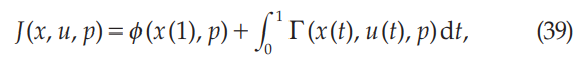

#### Terminal Cost $\phi(x(1), p)$

Altitude : $r_z^2$ (helps regularize the problem)

Final Time: $0.1 \frac{t_f}{t_{fmin}}$ 

$$\phi(x(1),p) = r_z^2 + 0.1 \frac{t_f}{t_{fmin}}$$

In [10]:
ϕ(x, p) = x[3]^2 + p[1] / tf_min * 0.1;

#### Running Cost $\Gamma(x(t), u(t), p)$

Thrust: $\frac{||T||}{T_{max}} = \frac{\sigma}{T_{max}}$ (necessary for Lossless Convexification to work)

Vane Angle: $(100\frac{\gamma}{\gamma_{max}})^2$

$$\Gamma(x(t),u(t),p) = \frac{\sigma}{T_{max}} + (100\frac{\gamma}{\gamma_{max}})^2$$

In [11]:
Γ(x, u, p) = u[4] / T_max_ + (u[5] / γ_max_ * 100)^2;

#### Cost Function

$$J(x,u,p) = r_z^2 + 0.1 \frac{t_f}{t_{fmin}} + \int_{t_i}^{t_f}\frac{\sigma}{T_{max}} + (100\frac{\gamma}{\gamma_{max}})^2 dt$$

## SCP Problem Definition

SCP: Successive Convex Programming

### Optimal Control Optimization Problem Definition

#### General Form

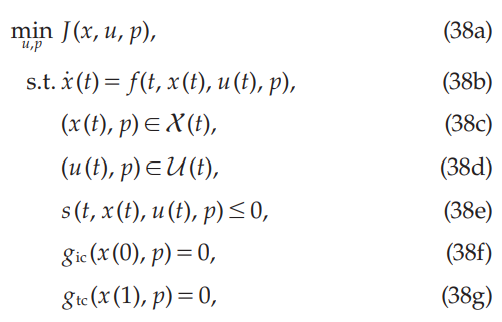

where $\mathcal{X}$ is the set of states that satisfy the convex state constraints, $\mathcal{U}$ is the set of controls that satisfy the convex control constraints, $s(t, x(t), u(t), p)$ is the nonconvex path constraint, $g_{ic}$ is the initial condition, and $g_{tc}$ is the terminal condition.

### SCP Optimization Problem Definition

Scale the dynamics by the final time so that the final time can be a free parameter.

In [12]:
f_n = f_ * t_f

12-element Vector{Num}:
                                                                                                                                              t_f*v₁
                                                                                                                                              t_f*v₂
                                                                                                                                              t_f*v₃
                                                                                      ((T₁*cos(θ₂) + T₂*sin(θ₁)*sin(θ₂) - T₃*sin(θ₂)*cos(θ₁))*t_f*cos(γ)) / m
                      ((T₁*sin(θ₃)*sin(θ₂) + T₂*(cos(θ₃)*cos(θ₁) - cos(θ₂)*sin(θ₁)*sin(θ₃)) + T₃*(cos(θ₃)*sin(θ₁) + cos(θ₂)*sin(θ₃)*cos(θ₁)))*t_f*cos(γ)) / m
 (-g + ((T₁*cos(θ₃)*sin(θ₂) + T₂*(-sin(θ₃)*cos(θ₁) - cos(θ₂)*cos(θ₃)*sin(θ₁)) + T₃*(-sin(θ₁)*sin(θ₃) + cos(θ₂)*cos(θ₃)*cos(θ₁)))*cos(γ)) / m)*t_f
                                                                   

#### Jacobian Calculations

State: $A = \nabla_x f =$

In [13]:
A_l = Symbolics.jacobian(f_n, x)

12×12 Matrix{Num}:
 0  0  0  t_f   0    0   …               0
 0  0  0   0   t_f   0                   0
 0  0  0   0    0   t_f                  0
 0  0  0   0    0    0                   0
 0  0  0   0    0    0                   0
 0  0  0   0    0    0   …               0
 0  0  0   0    0    0                 (t_f*cos(θ₃)) / sin(θ₂)
 0  0  0   0    0    0                 -t_f*sin(θ₃)
 0  0  0   0    0    0                (-t_f*cos(θ₂)*cos(θ₃)) / sin(θ₂)
 0  0  0   0    0    0       ((J₂ - J₃)*t_f*ω₂) / J₁
 0  0  0   0    0    0   …  ((-J₁ + J₃)*t_f*ω₁) / J₂
 0  0  0   0    0    0                   0

Control: $B = \nabla_u f =$

In [14]:
B_l = Symbolics.jacobian(f_n, u)

12×5 Matrix{Num}:
      0                                                       …                                                                                                                              0
      0                                                                                                                                                                                      0
      0                                                                                                                                                                                      0
    (t_f*cos(γ)*cos(θ₂)) / m                                                                                                       (-(T₁*cos(θ₂) + T₂*sin(θ₁)*sin(θ₂) - T₃*sin(θ₂)*cos(θ₁))*t_f*sin(γ)) / m
    (t_f*cos(γ)*sin(θ₃)*sin(θ₂)) / m                               (-(T₁*sin(θ₃)*sin(θ₂) + T₂*(cos(θ₃)*cos(θ₁) - cos(θ₂)*sin(θ₁)*sin(θ₃)) + T₃*(cos(θ₃)*sin(θ₁) + cos(θ₂)*sin(θ₃)*cos(θ₁)))*t_f*sin(γ)) / m
 

Parameter: $F = \nabla_p f =$

In [15]:
F_l = Symbolics.jacobian(f_n, p)

12×1 Matrix{Num}:
                                                                                                                                         v₁
                                                                                                                                         v₂
                                                                                                                                         v₃
                                                                        ((T₁*cos(θ₂) + T₂*sin(θ₁)*sin(θ₂) - T₃*sin(θ₂)*cos(θ₁))*cos(γ)) / m
        ((T₁*sin(θ₃)*sin(θ₂) + T₂*(cos(θ₃)*cos(θ₁) - cos(θ₂)*sin(θ₁)*sin(θ₃)) + T₃*(cos(θ₃)*sin(θ₁) + cos(θ₂)*sin(θ₃)*cos(θ₁)))*cos(γ)) / m
 -g + ((T₁*cos(θ₃)*sin(θ₂) + T₂*(-sin(θ₃)*cos(θ₁) - cos(θ₂)*cos(θ₃)*sin(θ₁)) + T₃*(-sin(θ₁)*sin(θ₃) + cos(θ₂)*cos(θ₃)*cos(θ₁)))*cos(γ)) / m
                                                                                            (sin(θ₃)*ω₂) / sin(θ₂) + (cos(θ₃)*ω₃) / sin(θ₂)
  

Nonconvex Path Constraint

N/A - No nonconvex path constraints 

In [16]:
#C_l = Symbolics.jacobian(s_n, x)
#D_l = Symbolics.jacobian(s_n, u)
#G_l = Symbolics.jacobian(s_n, p)

Boundary Conditions 

Initial conditions: $H_0 = \nabla_x g_{ic} =$

In [17]:
#K_0 = Symbolics.jacobian(g_ic, p)

H_0 = Symbolics.jacobian(g_ic, x)

12×12 Matrix{Num}:
 1  0  0  0  0  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0
 0  0  0  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0
 0  0  0  0  0  0  0  0  0  1  0  0
 0  0  0  0  0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  0  0  0  0  1

Terminal conditions: $H_f = \nabla_x g_{tc} =$

In [18]:
#K_f = Symbolics.jacobian(g_tc, p)

H_f = Symbolics.jacobian(g_tc, x)

12×12 Matrix{Num}:
 1  0  0  0  0  0  0  0  0  0  0  0
 0  1  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0
 0  0  0  0  1  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0
 0  0  0  0  0  0  0  0  1  0  0  0
 0  0  0  0  0  0  0  0  0  1  0  0
 0  0  0  0  0  0  0  0  0  0  1  0
 0  0  0  0  0  0  0  0  0  0  0  1

#### Linearized Optimization Problem Definition

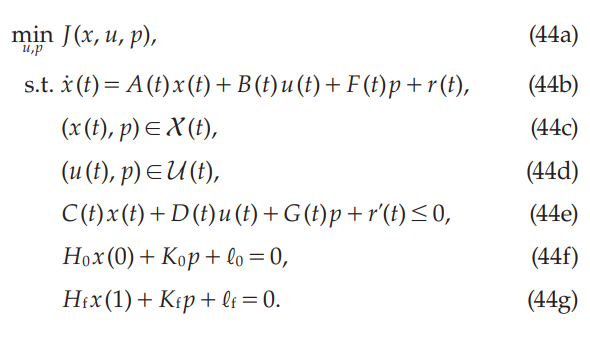

Note: Any jacobian not defined earlier is zero except $r$ and $r'$ which are derived from the other jacobians and dynamics.

### Initial Guess

The SCP algorithms do not require the initial guess to be feasible with respect to the dynamics or nonconvex path constraints, 
but they do require the guess to be feasible with respect to the convex path constraints

State

* r: Straight line interpolation
* v: Constant (from r)
* θ: Straight line interpolation
* ω: Constant (from θ)

Control

* T: 80% max thrust, no thrust vectoring: $T_{guess} = 0.8T_{max}\hat b_1$
* γ: Zero vane angle (should never be very large)

In [19]:
"""
    straightline_interpolate(v0, vf, N)

Straight-line interpolation between two points. Compute a straight-line
interpolation between an initial and a final vector, on a grid of N points.

# Arguments
- `v0`: starting vector.
- `vf`: ending vector.
- `N`: number of vectors in between (including endpoints).

# Returns
- `v`: the resulting interpolation (a matrix, k-th column is the k-th vector,
  k=1,...,N).
"""
function straightline_interpolate(v0::RealVector, vf::RealVector, N::Int)::RealMatrix

    # Initialize
    nv = length(v0)
    v = zeros(nv, N)

    # Interpolation grid
    times = LinRange(0.0, 1.0, N)
    t_endpts = [times[1], times[end]]
    v_endpts = hcat(v0, vf)

    for k = 1:N
        v[:, k] = linterp(times[k], v_endpts, t_endpts)
    end

    return v
end

"""
    get_interval(x, grid)

Compute grid bin. Get which grid interval a real number belongs to.

# Arguments
- `x`: the real number.
- `grid`: the discrete grid on the real line.

# Returns
- `k`: the interval of the grid the the real number is in.
"""
function get_interval(x::RealValue, grid::RealVector)::Int
    k = sum(x .> grid)
    if k == 0
        k = 1
    end
    return k
end

"""
    linterp(t, f_cps, t_grid)

Linear interpolation on a grid. Linearly interpolate a discrete function on a
time grid. In other words, get the function value assuming that it is a
continuous and piecewise affine function.

# Arguments
- `t`: the time at which to get the function value.
- `f_cps`: the control points of the function, stored as columns of a matrix.
- `t_grid`: the discrete time nodes.

# Returns
- `f_t`: the function value at time t.
"""
function linterp(
    t::RealValue,
    f_cps::RealArray,
    t_grid::RealVector,
)::Union{RealValue,RealArray}
    t = max(t_grid[1], min(t_grid[end], t)) # Saturate to time grid
    k = get_interval(t, t_grid)
    c = (t_grid[k+1] - t) / (t_grid[k+1] - t_grid[k])
    dimfill = fill(:, ndims(f_cps) - 1)
    f_t = c * f_cps[dimfill..., k] + (1 - c) * f_cps[dimfill..., k+1]
    return f_t
end;

In [20]:
# Terminal state
r1_ = zeros(3) # [m]
v1_ = zeros(3) # [m / s]
θ1_ = deg2rad.([0, 90, 0]) # [rad] 121 Euler sequence
θ1_[1] = θ0_[1]
ω1_ = zeros(3) # [rad / s]

x_f = [r1_; v1_; θ1_; ω1_];

# Control guess
T_guess = 0.8*T_max_ # [N] Initial thrust guess
input_guess(N) = straightline_interpolate([T_guess; 0; 0; T_guess; 0], [T_guess; 0; 0; T_guess; 0], N);

# Parameter guess
v_0, v_f = x_0[4:6], x_f[4:6]
tf_guess = norm(v_f-v_0 + sqrt.(2 * [0; 0; g_] * x_0[3]), 2)/(T_guess/m_-g_)

# State guess
state_guess(N) = begin
    x_guess = straightline_interpolate(x_0, x_f, N)
    x_guess[10, :] .= (x_f[7]-x_0[7])/tf_guess
    x_guess[11, :] .= (x_f[8]-x_0[8])/tf_guess
    x_guess[12, :] .= -(x_f[9]-x_0[9])/tf_guess
    return x_guess
end;

## SCP Toolbox Code and Solution

### Set Up Problem

The following code takes the above symbolic calculations and definitions and sets up the problem to be solved with SCPToolbox.

In [21]:
pbm = TrajectoryProblem();
algo = :ptr;

# Dimensions
n = length(x)
md = length(u)
d = length(p);
problem_set_dims!(pbm, n, md, d)

# Dynamics
build_func(func) = begin
    vfunc = eval(build_function(func, [x; u; p; c])[1]) 
    bfunc(t, k, x, u, p, pbm) = vfunc([x; u; p; c_])
    return bfunc
end;

problem_set_dynamics!(pbm, build_func(f_n), build_func(A_l), build_func(B_l), build_func(F_l))

# Boundary Conditions
build_bc(func) = begin
    vfunc = eval(build_function(func, [x; x0])[1]) 
    bfunc(x, p, pbm) = vfunc([x; x_0])
    return bfunc
end;

problem_set_bc!(pbm, :ic, build_bc(g_ic), build_bc(H_0))
problem_set_bc!(pbm, :tc, build_bc(g_tc), build_bc(H_f));

# Constraints
problem_set_X!(pbm, (t, k, x, p, pbm, clp) -> begin
        #@add_constraint(clp, NONPOS, p -> tf_min - p[1])
        #glideslope(x, clp)
        state_constraints(t, k, x, p, pbm, clp)
    end)

problem_set_U!(pbm, (t, k, u, p, pbm, clp) -> begin

        control_constraints(t, k, u, p, pbm, clp)
    end)

# Cost Function
problem_set_terminal_cost!(pbm, (x, p, pbm) -> ϕ(x, p))
problem_set_running_cost!(pbm, algo, (t, k, x, u, p, pbm) -> Γ(x, u, p))

# Initial Guess
problem_set_guess!(pbm, (N, pbm) -> begin
    x = state_guess(N)
    u = input_guess(N)
    p = [tf_guess]
    return x, u, p
end)

# Variable Scaling
rx_range_box = max(x_0[1], 1.0)
ry_range_box = max(x_0[2], 1.0)
rz_range_box = max(x_0[3], 1.0)
vx_range_box = max(abs(x_0[4]), 1.0)
vy_range_box = max(abs(x_0[5]), 1.0)
vz_range_box = min(x_0[6], -1.0)
θ_range_box = deg2rad(20.0)
ω_range_box = max(abs(x_0[10]), deg2rad(5.0))

thrust_range = (0, T_max_)

problem_advise_scale!(pbm, :state, 1, (-rx_range_box, rx_range_box))
problem_advise_scale!(pbm, :state, 2, (-ry_range_box, ry_range_box))
problem_advise_scale!(pbm, :state, 3, (0, rz_range_box))
problem_advise_scale!(pbm, :state, 4, (-vx_range_box, vx_range_box))
problem_advise_scale!(pbm, :state, 5, (-vy_range_box, vy_range_box))
problem_advise_scale!(pbm, :state, 6, (vz_range_box, 0.0))
problem_advise_scale!(pbm, :state, 7, (-θ_range_box, θ_range_box))
problem_advise_scale!(pbm, :state, 8, (-θ_range_box, θ_range_box))
problem_advise_scale!(pbm, :state, 9, (-θ_range_box, θ_range_box))
problem_advise_scale!(pbm, :state, 10, (-ω_range_box, ω_range_box))
problem_advise_scale!(pbm, :state, 11, (-ω_range_box, ω_range_box))
problem_advise_scale!(pbm, :state, 12, (-ω_range_box, ω_range_box))

problem_advise_scale!(pbm, :input, 1, thrust_range)
problem_advise_scale!(pbm, :input, 2, thrust_range)
problem_advise_scale!(pbm, :input, 3, thrust_range)
problem_advise_scale!(pbm, :input, 4, thrust_range)
problem_advise_scale!(pbm, :input, 5, (-γ_max_, γ_max_))

problem_advise_scale!(pbm, :parameter, 1, (0.5*tf_guess, tf_guess));

### Solve Optimization Problem

Define solver parameters, construct the optimization problem, and print the solution state at each solver iteration

In [22]:
# Parameters
N, Nsub = 12, 12
iter_max = 30
disc_method = FOH
wvc, wtr = 1e1, 1e-1
feas_tol = 5e-3
ε_abs, ε_rel = 1e-5, 1e-4
q_tr = Inf
q_exit = Inf
solver, solver_options = ECOS, Dict("verbose"=>0)      

pars = PTR.Parameters(N, Nsub, iter_max, disc_method, wvc, wtr, ε_abs,
                      ε_rel, feas_tol, q_tr, q_exit, solver, solver_options);

ptr_pbm = PTR.create(pars, pbm)
sol, history = PTR.solve(ptr_pbm);

k  | status   | vd    | vs    | vbc   | J         | ΔJ %      | Δx    | Δu    | Δp    | δ     | dyn | ηx    | ηu    | ηp   
---+----------+-------+-------+-------+-----------+-----------+-------+-------+-------+-------+-----+-------+-------+------
1  | OPTIMAL  | 4e+00 | 0e+00 | 3e-08 | 1.81e+00  |           | 1e+01 | 7e-01 | 4e-01 | 1e+01 | F   | 13.67 | 0.74  | 0.37 
2  | OPTIMAL  | 3e-04 | 0e+00 | 3e-09 | 1.49e+00  | 17.50     | 3e+00 | 7e-01 | 4e-01 | 3e+00 | F   | 2.85  | 0.72  | 0.38 
3  | ALMOST_O | 3e-04 | 0e+00 | 3e-08 | 1.32e+00  | 11.74     | 2e+00 | 4e-01 | 2e-06 | 2e+00 | F   | 2.34  | 0.42  | 0.00 
4  | OPTIMAL  | 8e-06 | 0e+00 | 2e-09 | 1.27e+00  | 3.41      | 5e-01 | 4e-01 | 8e-02 | 5e-01 | F   | 0.47  | 0.41  | 0.08 
5  | OPTIMAL  | 4e-06 | 0e+00 | 1e-09 | 1.25e+00  | 1.90      | 1e-01 | 4e-02 | 4e-03 | 1e-01 | F   | 0.10  | 0.04  | 0.00 
6  | OPTIMAL  | 6e-06 | 0e+00 | 2e-09 | 1.25e+00  | 0.35      | 7e-03 | 1e-03 | 2e-04 | 7e-03 | T   | 0.01  | 0.00  | 0.00 
7  | OPT

## Plot Solution

In [23]:
_sol = history.subproblems[end].sol

tf = _sol.p[1]
xd = _sol.xd
ud = _sol.ud
vd = _sol.vd
p_sol = _sol.p
td = sol.td*tf

Nc = 100
tc = LinRange(0, tf, Nc)
xc = hcat([sample(sol.xc, t) for t in LinRange(0, 1, Nc)]...)
uc = hcat([sample(sol.uc, t) for t in LinRange(0, 1, Nc)]...)

tf_values = [spbm.sol.p[1] for spbm in history.subproblems]
pushfirst!(tf_values, history.subproblems[1].ref.p[1]);

#[tf_guess, p_sol[1]]

The final time guess and final time of the solution are
$$
t_{fguess} = `{julia} round(tf_guess, digits = 3)`s
$$
$$
t_{f} = `{julia} round(p_sol[1], digits = 3)`s
$$

### No Control

Add gif of what happens with no control - 3d plot and 3d follow camera showing orientation

[ Info: Saved animation to C:\Users\thatf\Documents\PSP AC\Astra_SCP\src\tmp.gif


Plots.AnimatedGif("C:\\Users\\thatf\\Documents\\PSP AC\\Astra_SCP\\src\\tmp.gif")
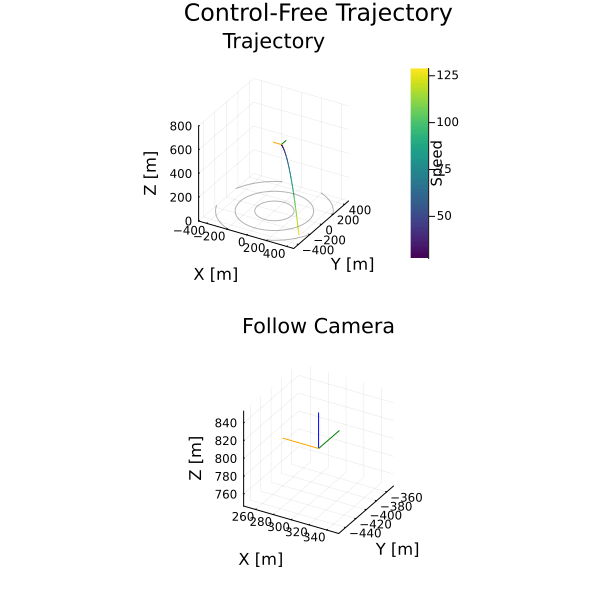

In [24]:
build_f(func) = begin
    vfunc = eval(build_function(func, [x; u; p; c])[1]) 
    bfunc(x, p, t) = vfunc([x; zeros(length(u)); [0]; c_])
    return bfunc
end;

f = build_f(f_)
tspan = (0.0, tf_guess)
prob = ODEProblem(f, x_0, tspan)
sol = solve(prob, Tsit5(), reltol = 1e-8, abstol = 1e-8);

r_ = stack([sol.u[i][1:3] for i in range(1, length(sol))], dims = 1)
valid_ind = r_[:, 3] .>= 0
r_[valid_ind, :];
xnc = stack([sol.u[i] for i in range(1, sum(valid_ind) + 1)], dims = 1)';

θ_ = xnc[7:9, :]
b_x = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [1, 0, 0] for i in range(1, (sum(valid_ind) + 1))]...)
b_y = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 1, 0] for i in range(1, (sum(valid_ind) + 1))]...)
b_z = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 0, 1] for i in range(1, (sum(valid_ind) + 1))]...)

Plots.gr()

velocity = [norm(xnc[4:6, i]) for i in range(1, (sum(valid_ind) + 1))]

a = Animation()

z_max = max(xnc[3, :]...)
x_lim = (min(min(xnc[1, :]...) - z_max / 10, -z_max / 10), max(max(xnc[1, :]...) + z_max / 10, z_max / 10))
y_lim = (min(min(xnc[2, :]...) - z_max / 10, -z_max / 10), max(max(xnc[2, :]...) + z_max / 10, z_max / 10))

ys = xs = LinRange(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2]), 100)
glide(x,y) = sqrt(x^2 + y^2) * tan(γ_gs_)
zs = [glide(x,y) for x in xs, y in ys]

for i in 1:(sum(valid_ind) + 1)

    l = @layout [a; b]

    p3 = Plots.plot(xnc[1, :], xnc[2, :], xnc[3, :], lc=:viridis, line_z=velocity, label = "", colorbar_title = "Speed")
    for cl in Contour.levels(Contour.contours(xs, ys, zs, 3))
        for line in Contour.lines(cl)
            _xs, _ys = Contour.coordinates(line) # coordinates of this line segment
            _zs = 0 * _xs
            plot!(p3, _xs, _ys, _zs, alpha=0.3, label = "", color = :black)        # add on x-y plane
        end
    end
    Plots.quiver!([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_x[1, i]], [b_x[2, i]], [b_x[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :blue, label = "b_x")
    Plots.quiver!([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_y[1, i]], [b_y[2, i]], [b_y[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :green, label = "b_y")
    Plots.quiver!([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_z[1, i]], [b_z[2, i]], [b_z[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :orange, label = "b_z", zlim=(0, z_max), ylim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])), xlim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])))
    Plots.title!("Trajectory")
    Plots.xlabel!("X [m]")
    Plots.ylabel!("Y [m]")
    Plots.zlabel!("Z [m]")

    p4 = Plots.quiver([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_x[1, i]], [b_x[2, i]], [b_x[3, i]]) .* z_max ./ 20, aspect_ratio=:equal, scene_aspectmode="cube", color = :blue, label = "b_x")
    Plots.quiver!([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_y[1, i]], [b_y[2, i]], [b_y[3, i]]) .* z_max ./ 20, aspect_ratio=:equal, scene_aspectmode="cube", color = :green, label = "b_y")
    Plots.quiver!([xnc[1, i]], [xnc[2, i]], [xnc[3, i]], quiver = ([b_z[1, i]], [b_z[2, i]], [b_z[3, i]]) .* z_max ./ 20, aspect_ratio=:equal, scene_aspectmode="cube", color = :orange, label = "b_z")
    
    Plots.xlims!((xnc[1, i] - z_max / 15, xnc[1, i] + z_max / 15))
    Plots.ylims!((xnc[2, i] - z_max / 15, xnc[2, i] + z_max / 15))
    Plots.zlims!((xnc[3, i] - z_max / 15, xnc[3, i] + z_max / 15))
    Plots.title!("Follow Camera")
    Plots.xlabel!("X [m]")
    Plots.ylabel!("Y [m]")
    Plots.zlabel!("Z [m]")
    
    plt = Plots.plot(p3, p4, layout = l, plot_title="Control-Free Trajectory", size = (600, 600), aspect_ratio = :equal, margin = 1mm)

    
    frame(a, plt)
end
	
gif(a, fps = 15)
#gif(a, "Trajectory_and_Orientation.gif", fps = 15)

### Initial Guess

[ Info: Saved animation to C:\Users\thatf\Documents\PSP AC\Astra_SCP\src\Trajectory_and_Orientation.gif


Plots.AnimatedGif("C:\\Users\\thatf\\Documents\\PSP AC\\Astra_SCP\\src\\Trajectory_and_Orientation.gif")
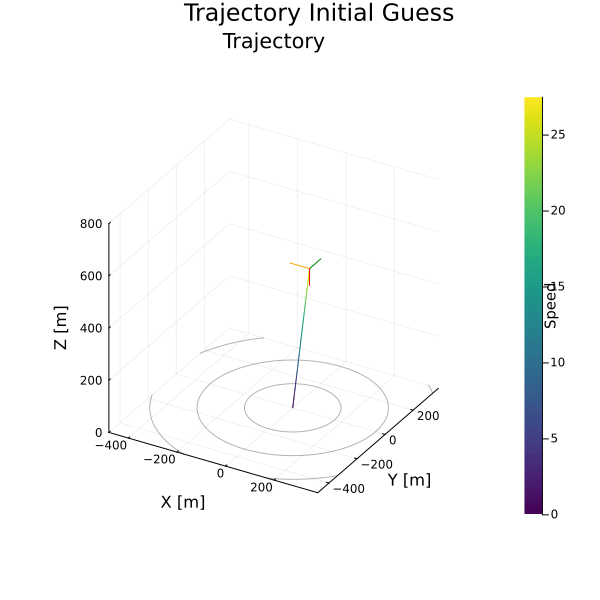

In [25]:
xi = state_guess(length(tc))
ui = input_guess(length(tc))

# define a function that returns a Plots.Shape
rectangle(w, h, x, y, bx) = begin 
    P = [-w/2 w/2 w/2 -w/2; 0 0 h h]
    by = [0 1; -1 0] * bx
    P_prime = hcat([[0 -1; 1 0] * [bx by] * P[:, i] for i in range(1, 4)]...)
    P_prime = P_prime .+ [x; y]
    
    return Shape(P_prime[1, :], P_prime[2, :])
end

rectangle_norot(w, h, x, y) = begin 
    P = [-w/2 w/2 w/2 -w/2; 0 0 h h]
    P = P .+ [x; y]
    
    return Shape(P[1, :], P[2, :])
end

Xd = xd[1, :]' .* ones(length(xd[2, :]))
Yd = ones(length(xd[1, :]))' .* xd[2, :]
Zd = sqrt.((Xd .^ 2 + Yd .^ 2)) * tan(γ_gs_);

θ_ = xi[7:9, :]
b_x = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [1, 0, 0] for i in range(1, length(tc))]...)
b_y = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 1, 0] for i in range(1, length(tc))]...)
b_z = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 0, 1] for i in range(1, length(tc))]...)

T_ = ui[1:3, :]
T_e = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * T_[:, i] for i in range(1, length(tc))]...)

gimbal_r = [acos(dot([1; 0; 0], T_[:, i]) / norm(T_[:, i])) * 180 / pi for i in range(1, length(tc))]
gimbal_θ = (atan.(ui[3,:], ui[2, :])) .+ pi 

Plots.gr()

velocity = [norm(xi[4:6, i]) for i in range(1, length(tc))]

a = Animation()

z_max = max(xi[3, :]...)
x_lim = (min(xi[1, :]...) - z_max / 10, max(xi[1, :]...) + z_max / 10)
y_lim = (min(xi[2, :]...) - z_max / 10, max(xi[2, :]...) + z_max / 10)

ys = xs = LinRange(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2]), 100)
glide(x,y) = sqrt(x^2 + y^2) * tan(γ_gs_)
zs = [glide(x,y) for x in xs, y in ys]

for i in 1:length(tc)

    l = @layout [a]

    p3 = Plots.plot(xi[1, :], xi[2, :], xi[3, :], lc=:viridis, line_z=velocity, label = "", colorbar_title = "Speed")
    for cl in Contour.levels(Contour.contours(xs, ys, zs, 3))
        for line in Contour.lines(cl)
            _xs, _ys = Contour.coordinates(line) # coordinates of this line segment
            _zs = 0 * _xs
            plot!(p3, _xs, _ys, _zs, alpha=0.3, label = "", color = :black)        # add on x-y plane
        end
    end
    Plots.quiver!([xi[1, i]], [xi[2, i]], [xi[3, i]], quiver = ([b_x[1, i]], [b_x[2, i]], [b_x[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :blue, label = "b_x")
    Plots.quiver!([xi[1, i]], [xi[2, i]], [xi[3, i]], quiver = ([b_y[1, i]], [b_y[2, i]], [b_y[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :green, label = "b_y")
    Plots.quiver!([xi[1, i]], [xi[2, i]], [xi[3, i]], quiver = ([b_z[1, i]], [b_z[2, i]], [b_z[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :orange, label = "b_z")
    Plots.plot!([xi[1, i], xi[1, i] - T_e[1, i] / T_max_ * z_max ./ 10], [xi[2, i], xi[2, i] - T_e[2, i] / T_max_ * z_max ./ 10], [xi[3, i], xi[3, i] - T_e[3, i] / T_max_ * z_max ./ 10], color = :red, axpect_ratio=:equal, label = "", zlim=(0, z_max), ylim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])), xlim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])))
    Plots.title!("Trajectory")
    Plots.xlabel!("X [m]")
    Plots.ylabel!("Y [m]")
    Plots.zlabel!("Z [m]")

    plt = Plots.plot(p3, layout = l, plot_title="Trajectory Initial Guess", size = (600, 600), aspect_ratio = :equal, margin = 1mm)

    
    frame(a, plt)
end
	
#gif(a, fps = 15)
gif(a, "Trajectory_and_Orientation.gif", fps = 15)

### Solution Gif

[ Info: Saved animation to C:\Users\thatf\Documents\PSP AC\Astra_SCP\src\Trajectory_and_Orientation.gif


Plots.AnimatedGif("C:\\Users\\thatf\\Documents\\PSP AC\\Astra_SCP\\src\\Trajectory_and_Orientation.gif")
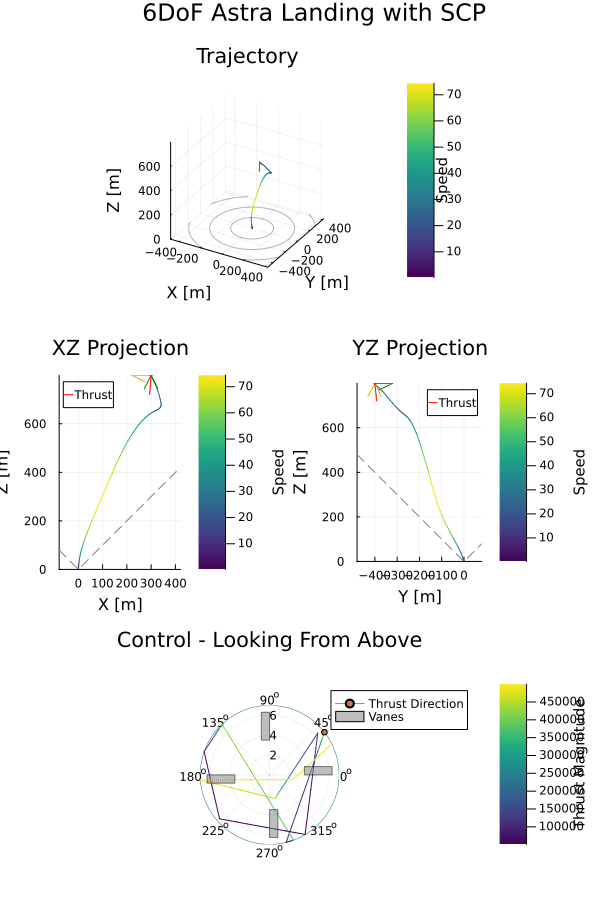

In [26]:
# define a function that returns a Plots.Shape
rectangle(w, h, x, y, bx) = begin 
    P = [-w/2 w/2 w/2 -w/2; 0 0 h h]
    by = [0 1; -1 0] * bx
    P_prime = hcat([[0 -1; 1 0] * [bx by] * P[:, i] for i in range(1, 4)]...)
    P_prime = P_prime .+ [x; y]
    
    return Shape(P_prime[1, :], P_prime[2, :])
end

rectangle_norot(w, h, x, y) = begin 
    P = [-w/2 w/2 w/2 -w/2; 0 0 h h]
    P = P .+ [x; y]
    
    return Shape(P[1, :], P[2, :])
end

Xd = xd[1, :]' .* ones(length(xd[2, :]))
Yd = ones(length(xd[1, :]))' .* xd[2, :]
Zd = sqrt.((Xd .^ 2 + Yd .^ 2)) * tan(γ_gs_);

θ_ = xc[7:9, :]
b_x = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [1, 0, 0] for i in range(1, length(tc))]...)
b_y = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 1, 0] for i in range(1, length(tc))]...)
b_z = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * [0, 0, 1] for i in range(1, length(tc))]...)

T_ = uc[1:3, :]
T_e = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * T_[:, i] for i in range(1, length(tc))]...)

gimbal_r = [acos(dot([1; 0; 0], T_[:, i]) / norm(T_[:, i])) * 180 / pi for i in range(1, length(tc))]
gimbal_θ = (atan.(uc[3,:], uc[2, :])) .+ pi 

Plots.gr()

velocity = [norm(xc[4:6, i]) for i in range(1, length(tc))]

a = Animation()

z_max = max(xc[3, :]...)
x_lim = (min(xc[1, :]...) - z_max / 10, max(xc[1, :]...) + z_max / 10)
y_lim = (min(xc[2, :]...) - z_max / 10, max(xc[2, :]...) + z_max / 10)

ys = xs = LinRange(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2]), 100)
glide(x,y) = sqrt(x^2 + y^2) * tan(γ_gs_)
zs = [glide(x,y) for x in xs, y in ys]

for i in 1:length(tc)

    l = @layout [a; b c; d]

    xz_angle = asin(norm(cross([b_x[1, i], 0, b_x[3, i]], [1,0,0])) / norm([b_x[1, i], 0, b_x[3, i]]))
    p1 = Plots.plot(xc[1, :], xc[3, :], lc=:viridis, line_z=velocity, label = "", colorbar_title = "Speed")
    Plots.quiver!([xc[1, i]], [xc[3, i]], quiver = ([b_x[1, i]], [b_x[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :blue, label = "b_x")
    Plots.quiver!([xc[1, i]], [xc[3, i]], quiver = ([b_y[1, i]], [b_y[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :green, label = "b_y")
    Plots.quiver!([xc[1, i]], [xc[3, i]], quiver = ([b_z[1, i]], [b_z[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :orange, label = "b_z")
    Plots.plot!([xc[1, i], xc[1, i] - T_e[1, i] / T_max_ * z_max ./ 10], [xc[3, i], xc[3, i] - T_e[3, i] / T_max_ * z_max ./ 10], color = :red, label = "Thrust", axpect_ratio=:equal, ylim=(0, z_max), xlim=x_lim)
    Plots.plot!(rectangle(z_max / 50,z_max / 20,xc[1, i],xc[3, i], [b_x[1, i]; b_x[3, i]]), label = "", opacity=.5, color = :gray)
    Plots.plot!(LinRange(x_lim[1], x_lim[2], 100), abs.(LinRange(x_lim[1], x_lim[2], 100)) * tan(γ_gs_), linestyle = :dash, label = "", color = :gray)
    Plots.title!("XZ Projection")
    Plots.xlabel!("X [m]")
    Plots.ylabel!("Z [m]")

    yz_angle = asin(norm(cross([0, b_x[2, i], b_x[3, i]], [1,0,0])) / norm([0, b_x[2, i], b_x[3, i]]))
    p2 = Plots.plot(xc[2, :], xc[3, :], lc=:viridis, line_z=velocity, label = "", colorbar_title = "Speed")
    Plots.quiver!([xc[2, i]], [xc[3, i]], quiver = ([b_x[2, i]], [b_x[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :blue, label = "b_x")
    Plots.quiver!([xc[2, i]], [xc[3, i]], quiver = ([b_y[2, i]], [b_y[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :green, label = "b_y")
    Plots.quiver!([xc[2, i]], [xc[3, i]], quiver = ([b_z[2, i]], [b_z[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, color = :orange, label = "b_z")
    Plots.plot!([xc[2, i], xc[2, i] - T_e[2, i] / T_max_ * z_max ./ 10], [xc[3, i], xc[3, i] - T_e[3, i] / T_max_ * z_max ./ 10], color = :red, label = "Thrust", axpect_ratio=:equal, ylim=(0, z_max), xlim=y_lim)
    Plots.plot!(rectangle(z_max / 50,z_max / 20,xc[2, i],xc[3, i], [b_x[2, i]; b_x[3, i]]), label = "", opacity=.5, color = :gray)
    Plots.plot!(LinRange(y_lim[1], y_lim[2], 100), abs.(LinRange(y_lim[1], y_lim[2], 100)) * tan(γ_gs_), linestyle = :dash, label = "", color = :gray)
    Plots.title!("YZ Projection")
    Plots.xlabel!("Y [m]")
    Plots.ylabel!("Z [m]")

    p3 = Plots.plot(xc[1, :], xc[2, :], xc[3, :], lc=:viridis, line_z=velocity, label = "", colorbar_title = "Speed")
    Plots.quiver!([xc[1, i]], [xc[2, i]], [xc[3, i]], quiver = ([b_x[1, i]], [b_x[2, i]], [b_x[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :blue, label = "b_x")
    for cl in Contour.levels(Contour.contours(xs, ys, zs, 3))
        for line in Contour.lines(cl)
            _xs, _ys = Contour.coordinates(line) # coordinates of this line segment
            _zs = 0 * _xs
            plot!(p3, _xs, _ys, _zs, alpha=0.3, label = "", color = :black)        # add on x-y plane
        end
    end
    Plots.quiver!([xc[1, i]], [xc[2, i]], [xc[3, i]], quiver = ([b_y[1, i]], [b_y[2, i]], [b_y[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :green, label = "b_y")
    Plots.quiver!([xc[1, i]], [xc[2, i]], [xc[3, i]], quiver = ([b_z[1, i]], [b_z[2, i]], [b_z[3, i]]) .* z_max ./ 10, aspect_ratio=:equal, scene_aspectmode="cube", color = :orange, label = "b_z")
    Plots.plot!([xc[1, i], xc[1, i] - T_e[1, i] / T_max_ * z_max ./ 10], [xc[2, i], xc[2, i] - T_e[2, i] / T_max_ * z_max ./ 10], [xc[3, i], xc[3, i] - T_e[3, i] / T_max_ * z_max ./ 10], color = :red, axpect_ratio=:equal, label = "", zlim=(0, z_max), ylim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])), xlim=(min(x_lim[1], y_lim[1]), max(x_lim[2], y_lim[2])))
    Plots.title!("Trajectory")
    Plots.xlabel!("X [m]")
    Plots.ylabel!("Y [m]")
    Plots.zlabel!("Z [m]")

    p5 = Plots.plot(gimbal_θ, gimbal_r, proj = :polar, lc = :viridis, line_z = uc[4, :], label = "", colorbar_title = "Thrust Magnitude", ylim = [0, δ_max_ * 180 / pi], yticks=2:2:ceil(δ_max_ * 180 / pi))
    Plots.plot!([gimbal_θ[i]], [gimbal_r[i]], proj = :polar, m = 3, label = "Thrust Direction")
    th = uc[5, i] * 5
    Plots.plot!(rectangle_norot(abs(sin(th)),0.4,sin(th)/2,0.5), label = "Vanes", opacity=.5, color = :gray)
    Plots.plot!(rectangle_norot(abs(sin(-th)),-0.4,sin(-th)/2,-0.5), label = "", opacity=.5, color = :gray)
    Plots.plot!(rectangle_norot(0.4,sin(-th),0.7,0), label = "", opacity=.5, color = :gray)
    Plots.plot!(rectangle_norot(0.4,sin(th),-0.7,0), label = "", opacity=.5, color = :gray)
    Plots.title!("Control - Looking From Above")

    
    plt = Plots.plot(p3, p1, p2, p5, layout = l, widths = (1, 4/8, 4/8, 1), plot_title="6DoF Astra Landing with SCP", size = (600, 900), aspect_ratio = :equal, margin = 1mm)

    
    frame(a, plt)
end
	
#gif(a, fps = 15)
gif(a, "Trajectory_and_Orientation.gif", fps = 15)

### Interactive 3D Trajectory View

Ignore the error from the next plot

WebIO._IJuliaInit()

┌ Warning: It looks like the Kaleido process is not responding. 
│ The unresponsive process will be killed, but this means that you will not be able to save figures using `savefig`.
│ 
│ If you are on Windows this might be caused by known problems with Kaleido v0.2 on Windows (you are using version 0.2.1).
│ You might want to try forcing a downgrade of the Kaleido_jll library to 0.1.
│ Check the Package Readme at https://github.com/JuliaPlots/PlotlyKaleido.jl/tree/main#windows-note for more details.
│ 
│ If you think this is not your case, you might try using a longer timeout to check if the process is not responding (defaults to 10 seconds) by passing the desired value in seconds using the `timeout` kwarg when calling `PlotlyKaleido.start` or `PlotlyKaleido.restart`
└ @ PlotlyKaleido C:\Users\thatf\.julia\packages\PlotlyKaleido\uMRVG\src\PlotlyKaleido.jl:24
┌ Warning: It looks like the Kaleido process is not responding. 
│ The unresponsive process will be killed, but this means that y

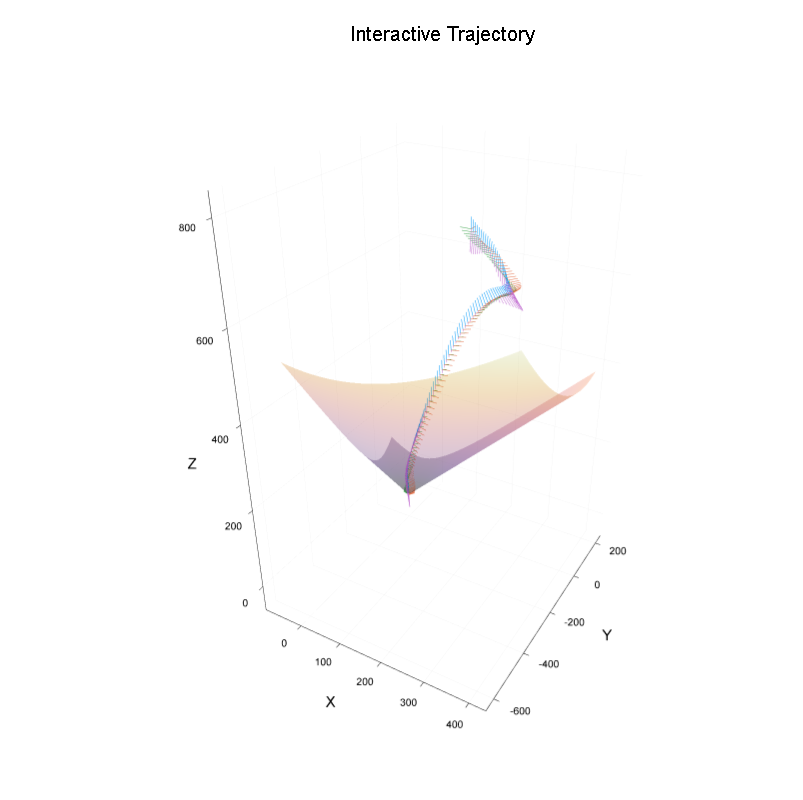

In [27]:
Xd = LinRange(x_lim[1], x_lim[2], 100)' .* ones(100)
Yd = ones(100)' .* LinRange(y_lim[1], y_lim[2], 100)
Zd = sqrt.((Xd .^ 2 + Yd .^ 2)) * tan(γ_gs_);

T_ = uc[1:3, :]
θ_ = xc[7:9, :]
#T_e = hcat([substitute(C_be, Dict([θ[1] => θ_[1, i], θ[2] => θ_[2, i], θ[3] => θ_[3, i]]))' * T_[:, i] for i in range(1, length(tc))]...)

Plots.plotlyjs()   # set the backend to Plotly

Plots.quiver(xc[1, :], xc[2, :], xc[3, :], quiver = (b_x[1, :], b_x[2, :], b_x[3, :]) .* z_max ./ 40, aspect_ratio=:equal, size = (500, 800), label = "Body X")
Plots.quiver!(xc[1, :], xc[2, :], xc[3, :], quiver = (b_y[1, :], b_y[2, :], b_y[3, :]) .* z_max ./ 40, aspect_ratio=:equal, label = "Body Y")
Plots.quiver!(xc[1, :], xc[2, :], xc[3, :], quiver = (b_z[1, :], b_z[2, :], b_z[3, :]) .* z_max ./ 40, aspect_ratio=:equal, label = "Body Z")
Plots.quiver!(xc[1, :], xc[2, :], xc[3, :], quiver = (-T_e[1, :], -T_e[2, :], -T_e[3, :]) ./ T_max_ .* z_max ./ 20, axpect_ratio=:equal, scene_aspectmode="cube", label = "Thrust", legend = :right)
Plots.surface!(Xd, Yd, Zd, aspect_ratio=:equal, colorbar = false, alpha = 0.5) # Glideslope
Plots.title!("Interactive Trajectory")
Plots.xlabel!("X")
Plots.ylabel!("Y")
Plots.zlabel!("Z")

### State Plots

The solver solved the problem by optimizing over the discrete trajectory. To check if the solution is still valid in the continuous case, the solution is propagated using a much finer time step to approximate the continuous trajectory. If the solution is good, the two trajectories should match well.

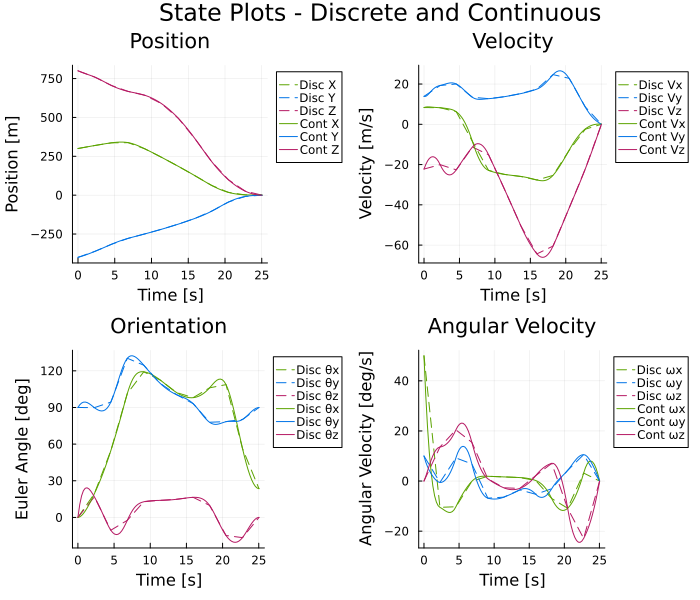

In [28]:
Plots.gr()

l = @layout [a b; c d]

plt_r = Plots.plot(td, xd[1, :], label = "Disc X", color = "#5ba300", linestyle = :dash)
Plots.plot!(td, xd[2, :], label = "Disc Y", color = "#0073e6", linestyle = :dash)
Plots.plot!(td, xd[3, :], label = "Disc Z", color = "#b51963", linestyle = :dash)
Plots.plot!(tc, xc[1, :], label = "Cont X", color = "#5ba300")
Plots.plot!(tc, xc[2, :], label = "Cont Y", color = "#0073e6")
Plots.plot!(tc, xc[3, :], label = "Cont Z", color = "#b51963", legend = :outertopright)
Plots.title!("Position")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Position [m]")

plt_v = Plots.plot(td, xd[4, :], label = "Disc Vx", color = "#5ba300", linestyle = :dash)
Plots.plot!(td, xd[5, :], label = "Disc Vy", color = "#0073e6", linestyle = :dash)
Plots.plot!(td, xd[6, :], label = "Disc Vz", color = "#b51963", linestyle = :dash)
Plots.plot!(tc, xc[4, :], label = "Cont Vx", color = "#5ba300")
Plots.plot!(tc, xc[5, :], label = "Cont Vy", color = "#0073e6")
Plots.plot!(tc, xc[6, :], label = "Cont Vz", color = "#b51963", legend = :outertopright)
Plots.title!("Velocity")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Velocity [m/s]")

plt_θ = Plots.plot(td, xd[7, :] * 180 / pi, label = "Disc θx", color = "#5ba300", linestyle = :dash)
Plots.plot!(td, xd[8, :] * 180 / pi, label = "Disc θy", color = "#0073e6", linestyle = :dash)
Plots.plot!(td, xd[9, :] * 180 / pi, label = "Disc θz", color = "#b51963", linestyle = :dash)
Plots.plot!(tc, xc[7, :] * 180 / pi, label = "Disc θx", color = "#5ba300")
Plots.plot!(tc, xc[8, :] * 180 / pi, label = "Disc θy", color = "#0073e6")
Plots.plot!(tc, xc[9, :] * 180 / pi, label = "Disc θz", color = "#b51963", legend = :outertopright)
Plots.title!("Orientation")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Euler Angle [deg]")

plt_ω = Plots.plot(td, xd[10, :] * 180 / pi, label = "Disc ωx", color = "#5ba300", linestyle = :dash)
Plots.plot!(td, xd[11, :] * 180 / pi, label = "Disc ωy", color = "#0073e6", linestyle = :dash)
Plots.plot!(td, xd[12, :] * 180 / pi, label = "Disc ωz", color = "#b51963", linestyle = :dash)
Plots.plot!(tc, xc[10, :] * 180 / pi, label = "Cont ωx", color = "#5ba300")
Plots.plot!(tc, xc[11, :] * 180 / pi, label = "Cont ωy", color = "#0073e6")
Plots.plot!(tc, xc[12, :] * 180 / pi, label = "Cont ωz", color = "#b51963", legend = :outertopright)
Plots.title!("Angular Velocity")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Angular Velocity [deg/s]")

plt = Plots.plot(plt_r, plt_v, plt_θ, plt_ω, layout = l, widths = (1/2, 1/2, 1/2, 1/2), plot_title="State Plots - Discrete and Continuous", size = (700, 600), margin = 1mm)
#savefig(plt, "State_plots.png") # save the fig referenced by plot_ref as filename_string (such as "output.png")

### Control Plots

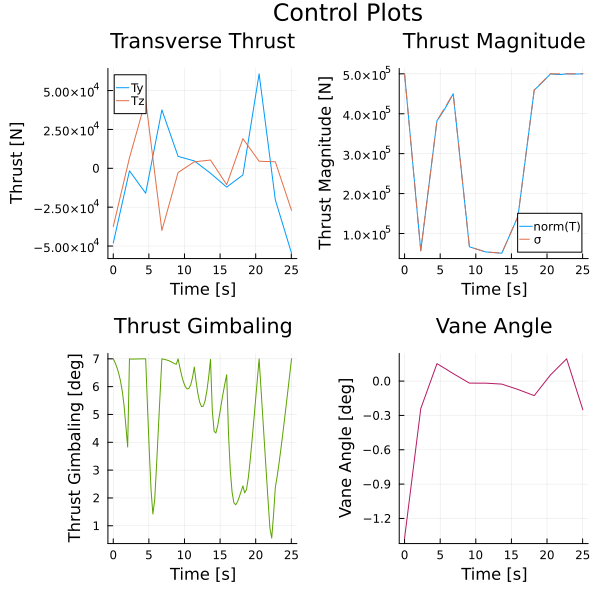

In [29]:
Plots.gr()

l = @layout [a b; c d]

plt_tT = Plots.plot(tc, uc[2, :], label = "Ty")
Plots.plot!(tc, uc[3, :], label = "Tz")
Plots.title!("Transverse Thrust")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Thrust [N]")

plt_σ = Plots.plot(tc, sqrt.(uc[1, :].^2 + uc[2, :].^2 + uc[3, :].^2), label = "norm(T)")
Plots.plot!(tc, uc[4, :], label = "σ", linestyle = :dash)
Plots.title!("Thrust Magnitude")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Thrust Magnitude [N]")

T_ = uc[1:3, :]
gimbal = [acos(dot([1; 0; 0], T_[:, i]) / norm(T_[:, i])) * 180 / pi for i in range(1, length(tc))]
plt_δ = Plots.plot(tc, gimbal, label = "", color = "#5ba300")
Plots.title!("Thrust Gimbaling")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Thrust Gimbaling [deg]")

plt_γ = Plots.plot(tc, uc[5, :]* 180 / pi, label = "", color = "#b51963")
Plots.title!("Vane Angle")
Plots.xlabel!("Time [s]")
Plots.ylabel!("Vane Angle [deg]")

plt = Plots.plot(plt_tT, plt_σ, plt_δ, plt_γ, layout = l, widths = (1/2, 1/2, 1/2, 1/2), plot_title="Control Plots", size = (600, 600), margin = 1mm)
#savefig(plt, "Control_plots.png") # save the fig referenced by plot_ref as filename_string (such as "output.png")